## Clustering analysis

After we preprocessed the data we now move onto the analysis itself. 

Written by autocomplete: The first step is to perform some exploratory data analysis (EDA) to understand the structure of the data and to identify any patterns or trends that may be present. This will help us to choose the appropriate clustering algorithm and to interpret the results of the clustering analysis.

## Imports


In [3]:
# Handy to have this for working with the xlsx mapping we had with the question number - question text pairs
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [9]:
# Data manipulation imports
import numpy as np
import pandas as pd

# Data visualisation imports
import matplotlib.pyplot as plt
import seaborn as sns

# ML and clustering imports
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram

# Extra clustering imports for Gower and PCA enhancements
from sklearn.decomposition import PCA
import gower
import scipy.spatial.distance as ssd
from scipy.cluster.hierarchy import linkage, fcluster

## Data loading and preparation

In [5]:
# Reading the pickle we perpared in data preprocessing
cleaned_df = pd.read_pickle('/Users/andrejsebo/Projects/clustering-project/data/processed/data_cleaned.pkl')

# Setting up the codebook to match question umbers with question texts
codebook_df = pd.read_excel('/Users/andrejsebo/Projects/clustering-project/data/raw/codebook.xlsx', header=None)

# Mapping
mapping = dict(zip(codebook_df[0], codebook_df[1]))

# Prepping model inputs - copy to avoid contamination
X = cleaned_df.copy()

# Converting to floats for potential experiments with gower 
X = X.astype(float)

# Quick checks
print(X.shape)
print(len(mapping))

(2312, 29)
29


## Comparing alternative combinations of distance and linkage calculations

As there are various combinations of distance and linkage calculation methods and we do not know in advance which one will bring the most interesting or sensible results, we decided to try out various combinations with a simple loop.

In [7]:
# 1. Defitiion of combinations we would like to see
experiments = [
    {'name': 'Euclidean + Ward', 'metric': 'euclidean', 'linkage': 'ward'},
    {'name': 'Manhattan + Average', 'metric': 'manhattan', 'linkage': 'average'},
    {'name': 'Jaccard + Complete', 'metric': 'jaccard', 'linkage': 'complete'},
    {'name': 'Cosine + Average', 'metric': 'cosine', 'linkage': 'average'}
]

results_summary = {}
experimental_labels = {}

# 2. Loop through combinations
for exp in experiments:
    model = AgglomerativeClustering(
        n_clusters=3, 
        metric=exp['metric'], 
        linkage=exp['linkage']
    )
    
    # Fit the model and get the labels
    labels = model.fit_predict(X)
    
    # Save the labels to dict
    experimental_labels[exp['name']] = labels
    
    # Get the sizes of the clusters (0, 1, 2)
    counts = pd.Series(labels).value_counts().to_dict()
    results_summary[exp['name']] = counts

# 3. Comparison table
comparison_table = pd.DataFrame(results_summary).fillna(0).astype(int)

# Rename the index for readability
comparison_table.index = ['Cluster 0', 'Cluster 1', 'Cluster 2']
print(comparison_table)

           Euclidean + Ward  Manhattan + Average  Jaccard + Complete  \
Cluster 0               960                    2                  51   
Cluster 1               865                    3                1989   
Cluster 2               487                 2307                 272   

           Cosine + Average  
Cluster 0                37  
Cluster 1              2270  
Cluster 2                 5  


In [8]:
from sklearn.decomposition import PCA

# 1. Pre-calculate the PCA data so we don't have to do it multiple times in the loop
# (We use 5 components here as a standard starting point)
pca = PCA(n_components=5, random_state=42)
X_pca = pca.fit_transform(X)

# 2. Add a 'use_pca' flag to your experiment definitions
experiments = [
    {'name': 'Raw: Euclidean + Ward', 'metric': 'euclidean', 'linkage': 'ward', 'use_pca': False},
    {'name': 'Raw: Jaccard + Complete', 'metric': 'jaccard', 'linkage': 'complete', 'use_pca': False},
    # Here is the new PCA challenger!
    {'name': 'PCA: Euclidean + Ward', 'metric': 'euclidean', 'linkage': 'ward', 'use_pca': True}
]

print("--- MODEL SHOWDOWN: CLUSTER SIZE DISTRIBUTIONS ---\n")
results_summary = {}
experimental_labels = {}

# 3. The smarter loop
for exp in experiments:
    
    # Initialize the model just like before
    model = AgglomerativeClustering(
        n_clusters=3, 
        metric=exp['metric'], 
        linkage=exp['linkage']
    )
    
    # THE UPGRADE: Choose which data to use based on the flag
    if exp['use_pca'] == True:
        data_to_fit = X_pca
    else:
        data_to_fit = X
        
    # Fit the model using the correct data
    labels = model.fit_predict(data_to_fit)
    
    # Save safely to our dictionary
    experimental_labels[exp['name']] = labels
    
    # Calculate sizes
    counts = pd.Series(labels).value_counts().to_dict()
    results_summary[exp['name']] = counts

# 4. Print the comparison table
comparison_table = pd.DataFrame(results_summary).fillna(0).astype(int)
comparison_table.index = ['Cluster 0', 'Cluster 1', 'Cluster 2']
print(comparison_table)

--- MODEL SHOWDOWN: CLUSTER SIZE DISTRIBUTIONS ---

           Raw: Euclidean + Ward  Raw: Jaccard + Complete  \
Cluster 0                    960                       51   
Cluster 1                    865                     1989   
Cluster 2                    487                      272   

           PCA: Euclidean + Ward  
Cluster 0                    775  
Cluster 1                    780  
Cluster 2                    757  


In [14]:
print("1. Pre-calculating heavy data... (this might take 10-20 seconds)")
# A. Pre-calculate PCA
pca = PCA(n_components=5, random_state=42)
X_pca = pca.fit_transform(X)

# B. Pre-calculate Gower & Square it (The legacy SAS/R trick)
gower_matrix = gower.gower_matrix(X)
gower_condensed = ssd.squareform(gower_matrix)
gower_squared = gower_condensed ** 2

# 2. Define the experiments with 'engine' and 'data' flags
experiments = [
    {'name': 'Euclidean + Ward', 'engine': 'sklearn', 'metric': 'euclidean', 'linkage': 'ward', 'data': 'raw'},
    {'name': 'Jaccard + Complete', 'engine': 'sklearn', 'metric': 'jaccard', 'linkage': 'complete', 'data': 'raw'},
    {'name': 'Euclidean + Ward (PCA)', 'engine': 'sklearn', 'metric': 'euclidean', 'linkage': 'ward', 'data': 'pca'},
    {'name': 'Gower + Ward', 'engine': 'scipy', 'matrix': gower_squared, 'linkage': 'ward'}
]

print("\n--- MODEL SHOWDOWN: CLUSTER SIZE DISTRIBUTIONS ---\n")
results_summary = {}
experimental_labels = {} 

# 3. The Multi-Engine Loop
for exp in experiments:
    
    if exp['engine'] == 'sklearn':
        # --- Language 1: Scikit-Learn ---
        model = AgglomerativeClustering(n_clusters=3, metric=exp['metric'], linkage=exp['linkage'])
        data_to_fit = X_pca if exp['data'] == 'pca' else X
        labels = model.fit_predict(data_to_fit)
        
    elif exp['engine'] == 'scipy':
        # --- Language 2: SciPy ---
        Z = linkage(exp['matrix'], method=exp['linkage'])
        # SciPy outputs 1, 2, 3 instead of 0, 1, 2. 
        # We subtract 1 so it matches scikit-learn perfectly in the final table!
        labels = fcluster(Z, t=3, criterion='maxclust') - 1 

    # Save safely to dictionary
    experimental_labels[exp['name']] = labels
    
    # Calculate sizes
    counts = pd.Series(labels).value_counts().to_dict()
    results_summary[exp['name']] = counts

# 4. Print the comparison table
comparison_table = pd.DataFrame(results_summary).fillna(0).astype(int)
comparison_table.index = ['Cluster 0', 'Cluster 1', 'Cluster 2']
print(comparison_table)

1. Pre-calculating heavy data... (this might take 10-20 seconds)

--- MODEL SHOWDOWN: CLUSTER SIZE DISTRIBUTIONS ---

           Euclidean + Ward  Jaccard + Complete  Euclidean + Ward (PCA)  \
Cluster 0               960                  51                     775   
Cluster 1               865                1989                     780   
Cluster 2               487                 272                     757   

           Gower + Ward  
Cluster 0          1205  
Cluster 1           266  
Cluster 2           841  


# Deeper look

Now that we see that Euclidean + Ward, PCA: Euclidean + Ward and Gower + Ward give us some sensible clusters, we investigate further to see how the clusters differ in answers across the questions. For these purposes we craete another simple function that will lets us visualise any of the clustering combinations easily.


In [15]:
def plot_cluster_profiles(model_name):
    # 1. Grab the raw labels from our loop's dictionary
    labels = experimental_labels[model_name]
    
    # 2. Building the visualisation df
    temp_df = X.copy()
    temp_df['Cluster'] = labels
    
    # Group by the cluster and calculate the mean (percentage of Yes)
    analysis = temp_df.groupby('Cluster').mean().T
    
    # Translate the question IDs to readable text using your dictionary
    analysis.index = analysis.index.map(lambda x: mapping.get(x, x))
    
    # --- YOUR EXACT PLOTTING CODE STARTS HERE ---
    
    # Create the plot directly from the DF
    analysis.plot(figsize=(15, 7), marker='o')

    # Add labels and titles (I made the title dynamic so it updates automatically!)
    plt.title(f"Cluster Profiles: {model_name} Average 'Yes' Rate")
    plt.ylabel("Percentage of Respondents (%)", fontsize=12)
    plt.xlabel("Survey Questions", fontsize=12)

    # Fix the X-Axis
    plt.xticks(range(len(analysis.index)), analysis.index, rotation=45, ha='right')

    # Add a grid so it's easier to see the values
    plt.grid(True, alpha=0.3)

    # Move the legend outside the box
    plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout() 
    plt.show()

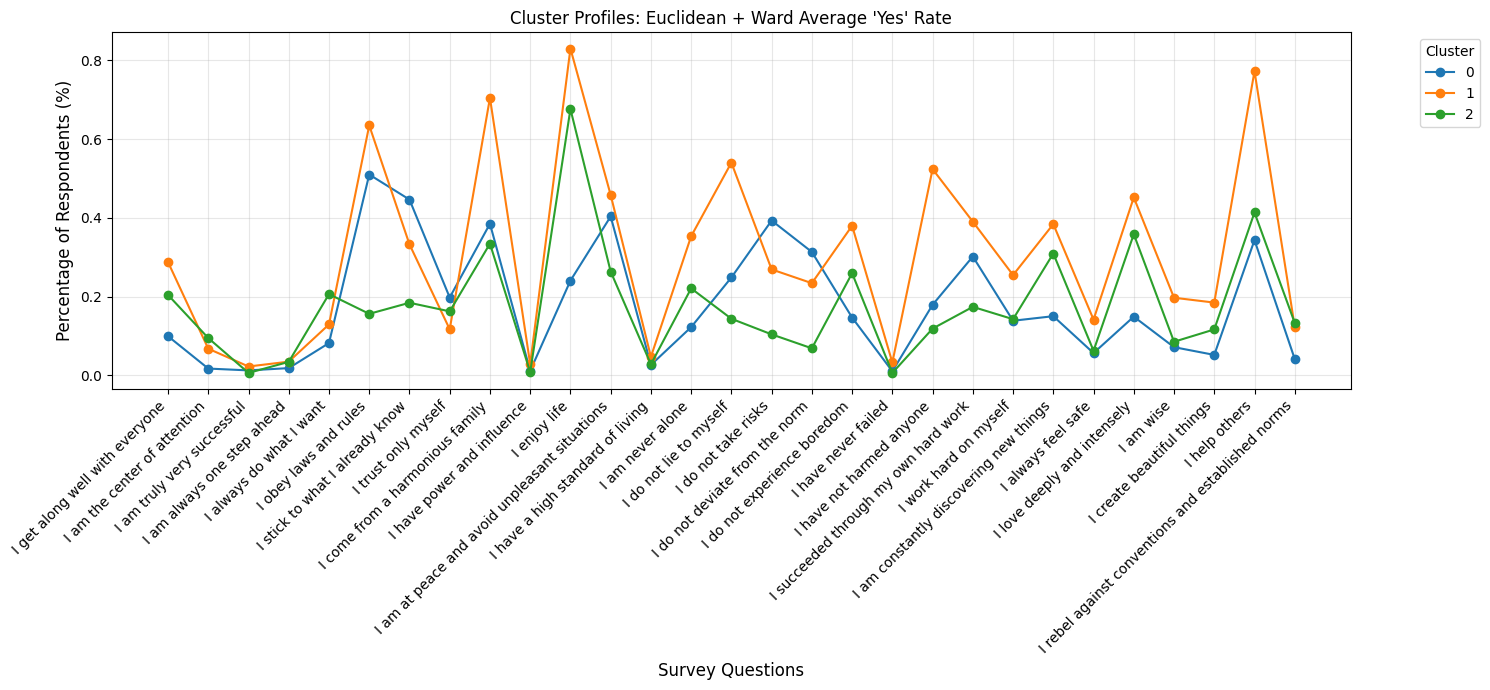

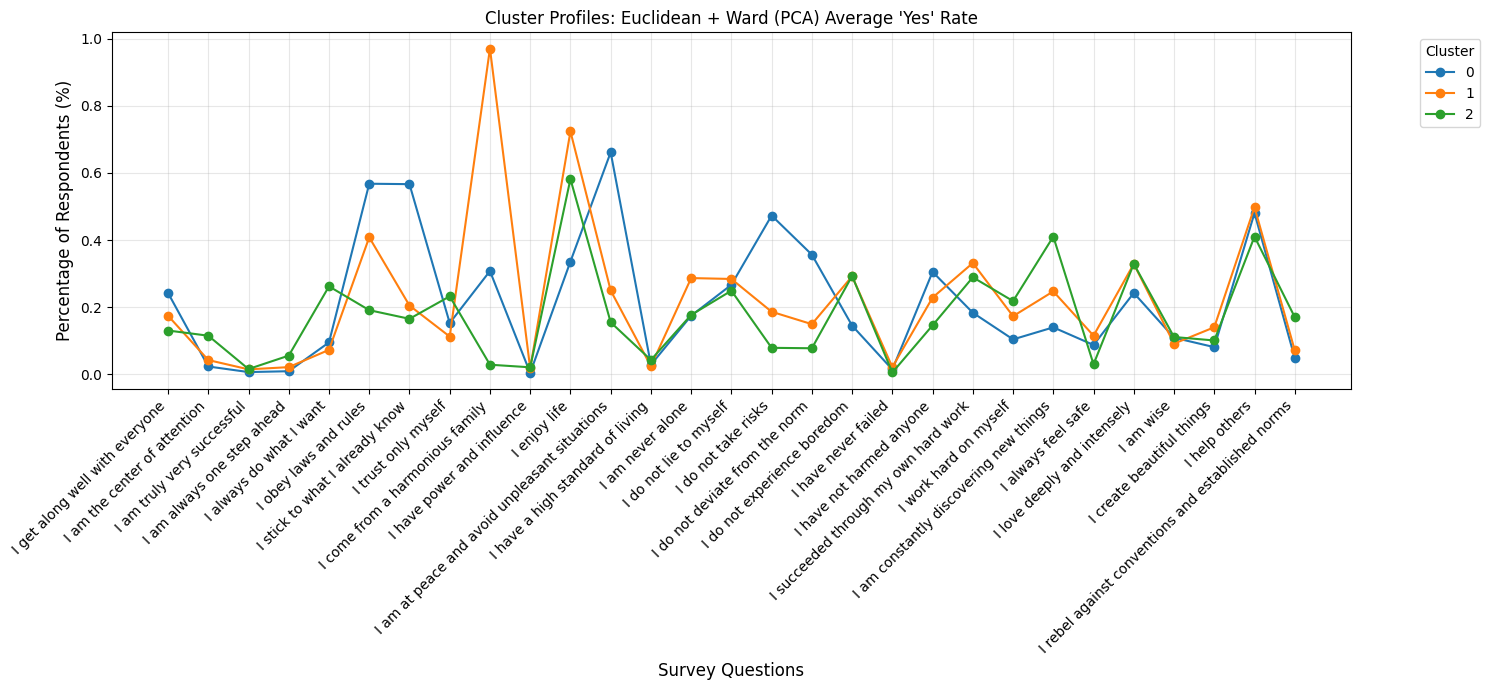

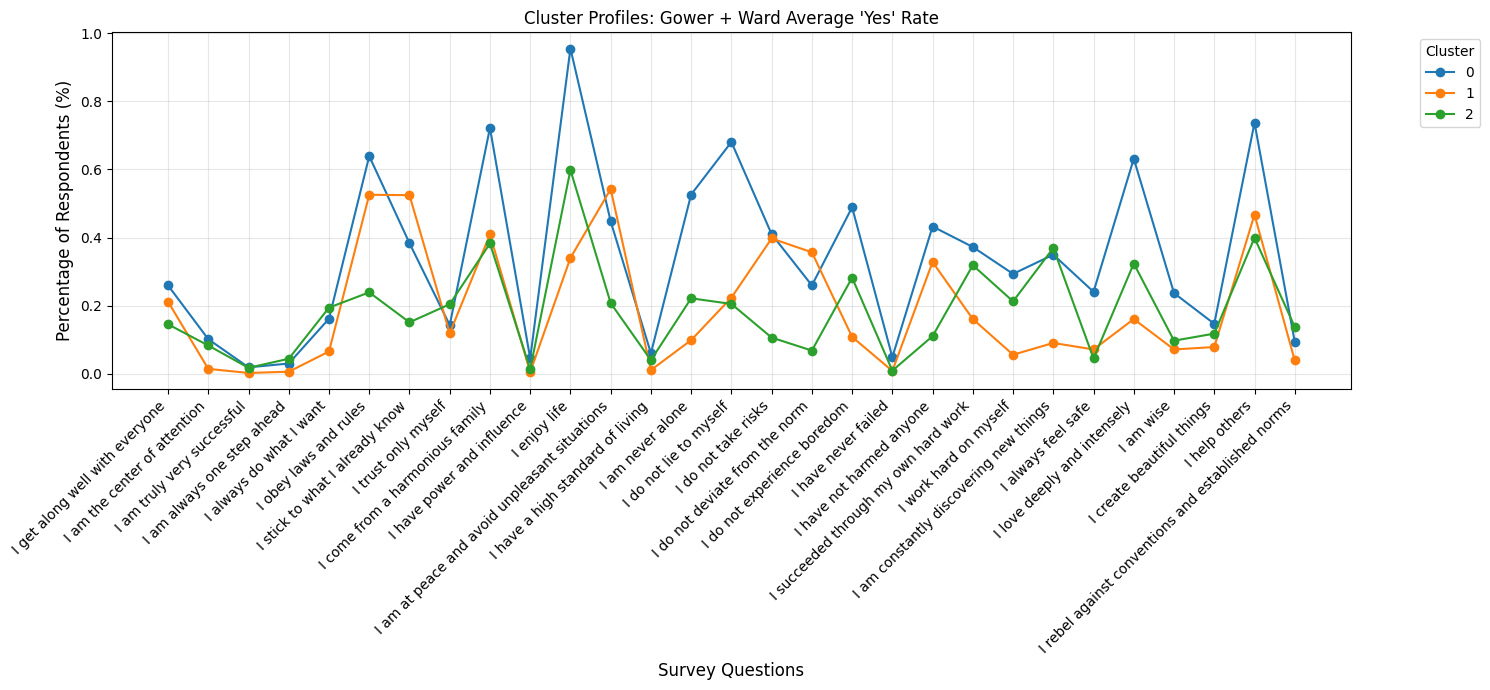

In [17]:
# Pass the exact names from your dictionary as text strings!
plot_cluster_profiles('Euclidean + Ward')
plot_cluster_profiles('Euclidean + Ward (PCA)')
plot_cluster_profiles('Gower + Ward')

## "Feature selection" for interpretability 

In [18]:
# ==========================================
# HIGH VARIANCE VISUALIZATION (Noise Reduction)
# ==========================================

def plot_top_variance_profiles(model_name):
    """
    Calculates the 'Rozsah' (variance) for each question, filters out 
    the bottom 50% of boring questions, and plots the polarizing ones.
    """
    # 1. Grab the raw labels
    labels = experimental_labels[model_name]
    
    # 2. Build the analysis dataframe safely
    temp_df = X.copy()
    temp_df['Cluster'] = labels
    
    # Group by the cluster and calculate the mean (percentage of Yes)
    analysis = temp_df.groupby('Cluster').mean().T
    
    # 3. Calculate the "Rozsah" (Max percentage - Min percentage)
    analysis['Rozsah'] = analysis.max(axis=1) - analysis.min(axis=1)
    
    # 4. Sort by highest variance and slice the top 50%
    # len(analysis) // 2 mathematically chops the list exactly in half
    top_half_count = len(analysis) // 2
    analysis = analysis.sort_values(by='Rozsah', ascending=False).head(top_half_count)
    
    # Drop the 'Rozsah' column now so it doesn't accidentally get drawn as a line on the graph!
    analysis = analysis.drop(columns=['Rozsah'])
    
    # 5. Translate the question IDs to readable text
    analysis.index = analysis.index.map(lambda x: mapping.get(x, x))
    
    # --- PLOTTING CODE ---
    analysis.plot(figsize=(15, 7), marker='o')

    plt.title(f"Defining Traits: {model_name} (Top 50% High Variance Questions)")
    plt.ylabel("Percentage of Respondents (%)", fontsize=12)
    plt.xlabel("Polarizing Survey Questions", fontsize=12)
    plt.xticks(range(len(analysis.index)), analysis.index, rotation=45, ha='right')
    plt.grid(True, alpha=0.3)
    plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout() 
    plt.show()

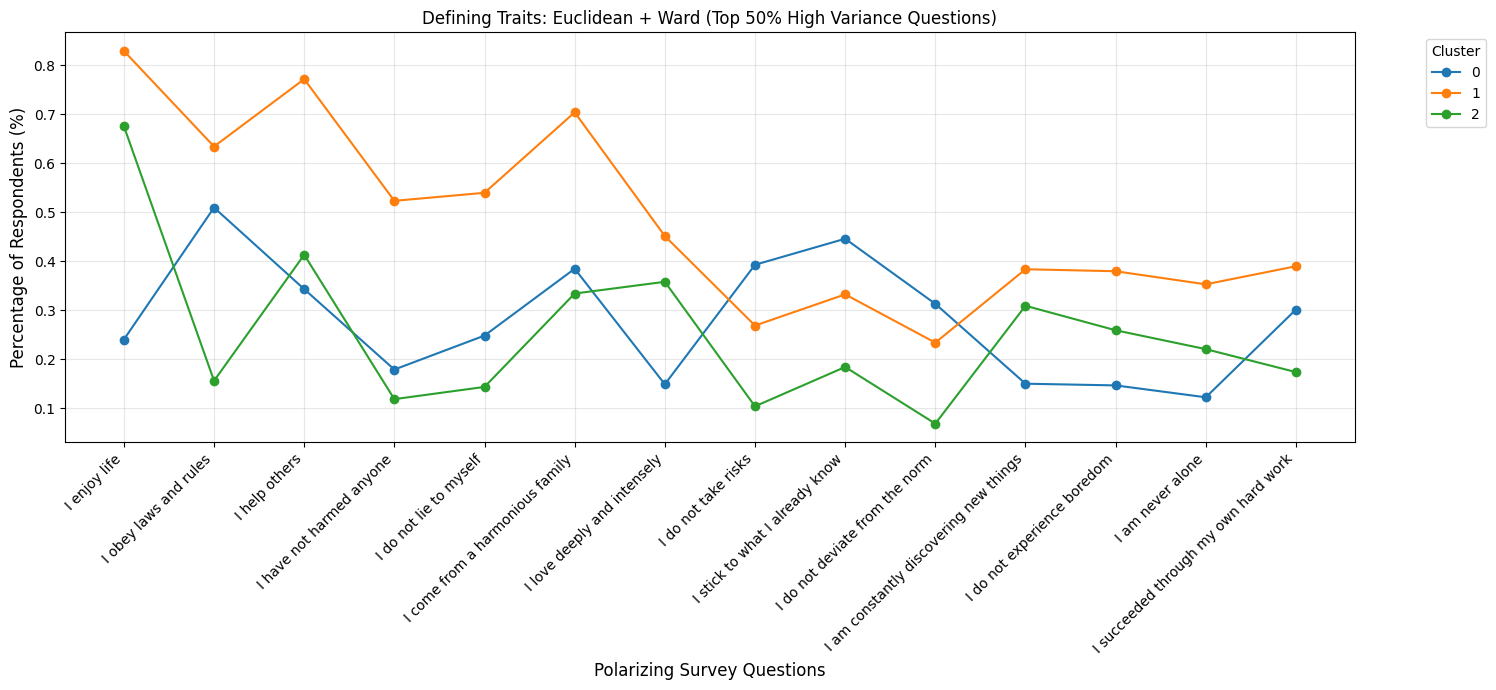

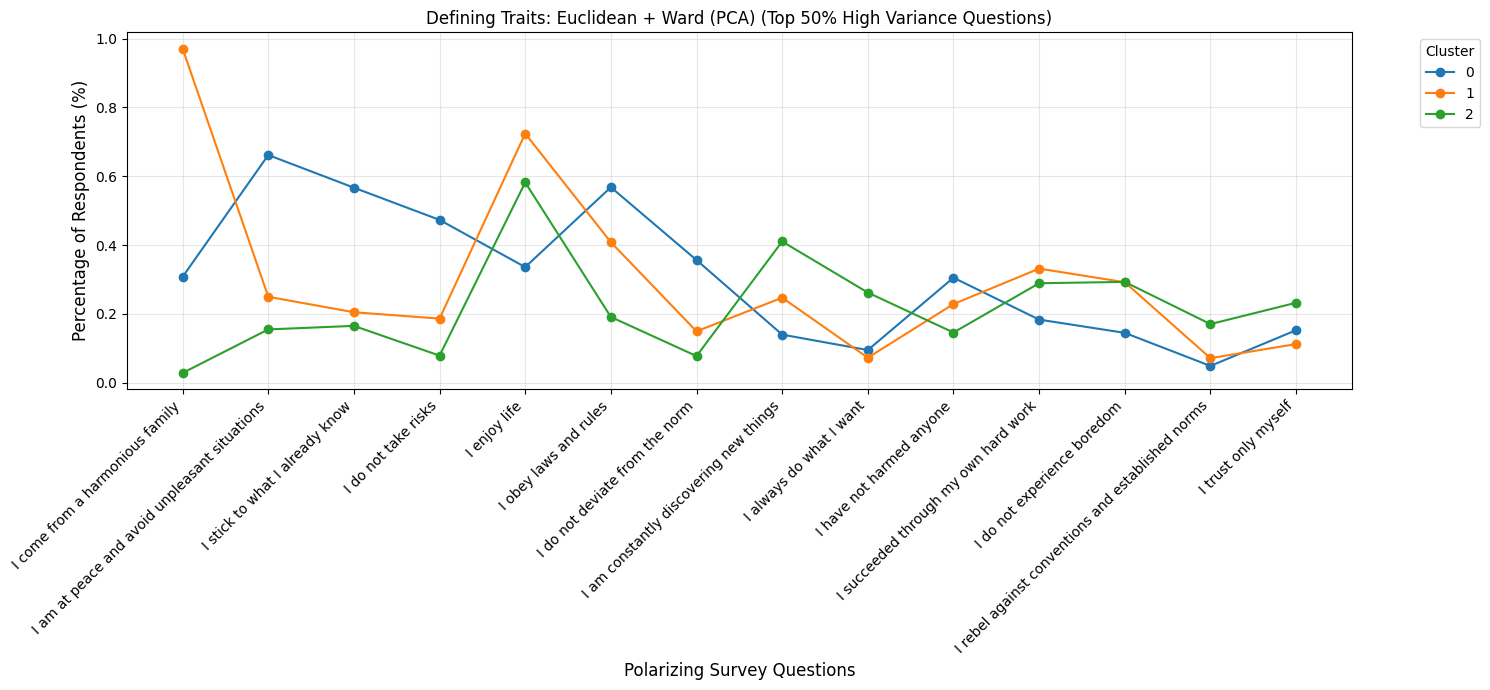

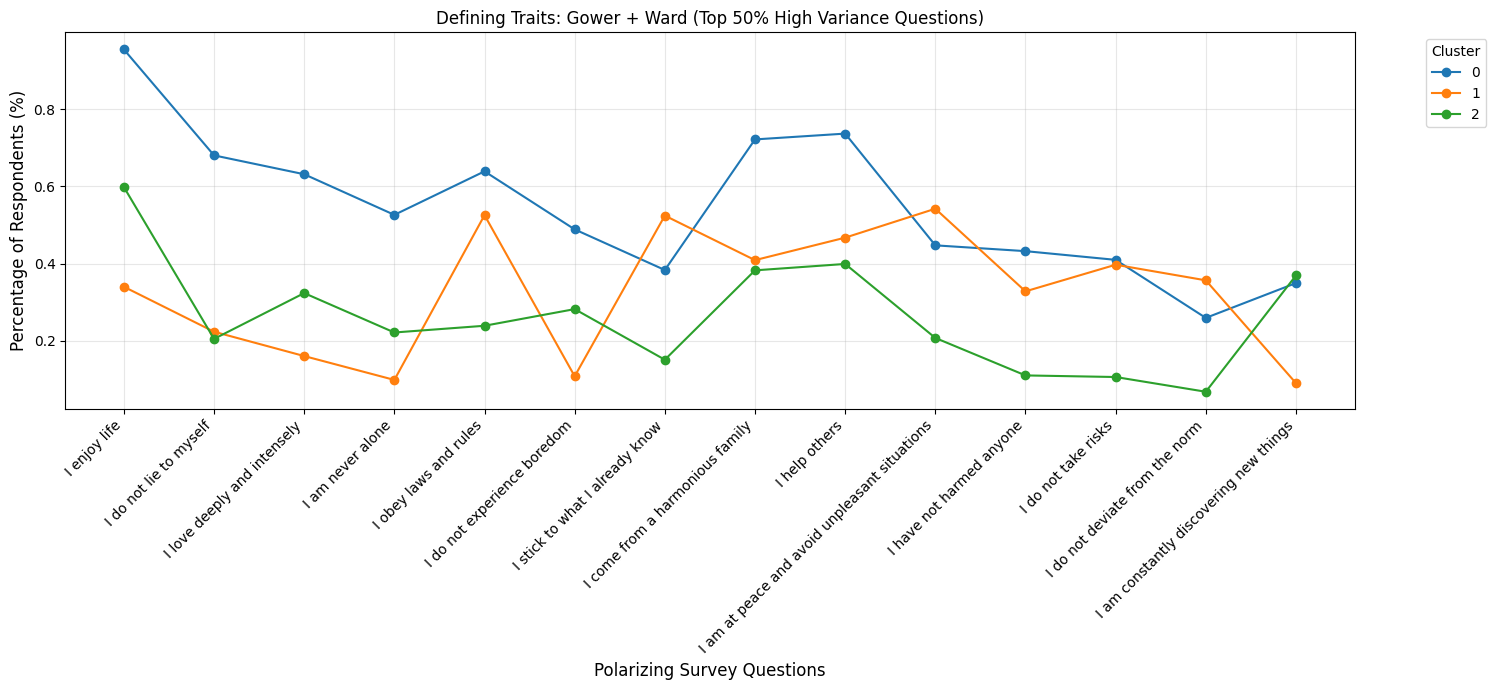

In [19]:
plot_top_variance_profiles('Euclidean + Ward')
plot_top_variance_profiles('Euclidean + Ward (PCA)')
plot_top_variance_profiles('Gower + Ward')

## Final cluster characterization

The PCA inclusion created clusters of repondents where questions mainly concerning the "peacefullness" of respondents proved to be a dimension along more pronounced differences can be spotted. To further characterize the clusters we now look at the top and bottom questions to whicch respondents from each of the clusters obtained by using PCA enhanced euclidean + ward combination of clustering arguments created.

In [20]:
# ==========================================
# DEEP DIVE: PCA MODEL PROFILES (HIGH VARIANCE ONLY)
# ==========================================

# 1. Select the specific model we want to deep dive into
model_name = 'Euclidean + Ward (PCA)'
labels = experimental_labels[model_name]

# 2. Combine pristine data (X) with the PCA labels
analysis_df = X.copy()
analysis_df['Cluster'] = labels

# 3. Group and calculate the averages
analysis = analysis_df.groupby('Cluster').mean().T

# 4. The "Rozsah" Filter: Calculate variance and keep only the top 50%
analysis['Rozsah'] = analysis.max(axis=1) - analysis.min(axis=1)
top_half_count = len(analysis) // 2

# Sort, slice the top half, and drop the Rozsah column so it doesn't mess up our math later
high_variance_analysis = analysis.sort_values(by='Rozsah', ascending=False).head(top_half_count)
high_variance_analysis = high_variance_analysis.drop(columns=['Rozsah'])

# 5. Translate the question codes to readable text
high_variance_analysis.index = high_variance_analysis.index.map(lambda x: mapping.get(x, x))

# 6. Print the final, noise-filtered profiles
print(f"Filtering out the {len(analysis) - top_half_count} least polarizing questions...\n")

for c in [0, 1, 2]:
    if c in high_variance_analysis.columns: 
        print(f"--- {model_name.upper()}: CLUSTER {c} ---")
        
        # Top 5 'Yes' answers from the defining questions
        top_5 = high_variance_analysis[c].nlargest(5)
        print("Top 5 Defining Agreements:")
        for question, value in top_5.items():
            print(f" - {question}: {value:.1%}")
            
        # Bottom 5 'Yes' answers from the defining questions
        bottom_5 = high_variance_analysis[c].nsmallest(5)
        print("\nTop 5 Defining Disagreements (Lowest Yes Rates):")
        for question, value in bottom_5.items():
            print(f" - {question}: {value:.1%}")
            
        print("\n" + "="*60 + "\n")

Filtering out the 15 least polarizing questions...

--- EUCLIDEAN + WARD (PCA): CLUSTER 0 ---
Top 5 Defining Agreements:
 - I am at peace and avoid unpleasant situations: 66.2%
 - I obey laws and rules: 56.8%
 - I stick to what I already know: 56.7%
 - I do not take risks: 47.3%
 - I do not deviate from the norm: 35.6%

Top 5 Defining Disagreements (Lowest Yes Rates):
 - I rebel against conventions and established norms: 4.9%
 - I always do what I want: 9.5%
 - I am constantly discovering new things: 14.0%
 - I do not experience boredom: 14.5%
 - I trust only myself: 15.3%


--- EUCLIDEAN + WARD (PCA): CLUSTER 1 ---
Top 5 Defining Agreements:
 - I come from a harmonious family: 97.1%
 - I enjoy life: 72.4%
 - I obey laws and rules: 40.8%
 - I succeeded through my own hard work: 33.2%
 - I do not experience boredom: 29.2%

Top 5 Defining Disagreements (Lowest Yes Rates):
 - I rebel against conventions and established norms: 7.1%
 - I always do what I want: 7.3%
 - I trust only myself: 1


The clustering analysis demonstrates that we can successfully extract meaningful, distinct psychological profiles from binary survey data. By filtering out general population noise (questions everyone agrees on) and isolating the traits with the highest variance between groups, the model revealed three highly actionable respondent segments:

Cluster 0: The Safe and Traditional
This group is defined by a strong preference for routine and stability. They are highly risk-averse, strictly obey rules and laws, and actively avoid unpleasant situations. They show almost zero desire to rebel or deviate from established societal norms.

Cluster 1: The Happy Family People
Anchored by an overwhelmingly high rate of family harmony (97%), this segment is content, rule-abiding, and deeply satisfied with life. They believe their success comes from their own hard work, striking a balance between traditional values and an active, boredom-free lifestyle.

Cluster 2: The Rebellious Explorers
Characterized by their thirst for novelty and independence, this group actively rejects traditional norms. They embrace risk, prioritize personal freedom ("I always do what I want"), and are constantly seeking to discover new things, often lacking the traditional family harmony seen in Cluster 1.

Final Takeaway: This project proves the core hypothesis of our methodology: when segmenting an audience, what makes a customer segment unique isn't what they agree with the most, but what they disagree on the most. By leveraging hierarchical clustering (PCA + Ward / Gower + Ward) and analyzing the maximum variance between groups, we have translated abstract survey data into clear, targetable human personas.
